In [76]:
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics

In [77]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv"
df = pd.read_csv(url)
df.sample(5)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
175,73,F,HIGH,HIGH,18.348,drugY
33,65,F,HIGH,NORMAL,31.876,drugY
157,53,M,LOW,HIGH,22.963,drugY
39,15,M,NORMAL,HIGH,9.084,drugX
28,39,F,LOW,NORMAL,22.697,drugY


In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    str    
 2   BP           200 non-null    str    
 3   Cholesterol  200 non-null    str    
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 9.5 KB


In [79]:
label_encoder = LabelEncoder()
df['Sex'] = label_encoder.fit_transform(df['Sex']) 
df['BP'] = label_encoder.fit_transform(df['BP'])
df['Cholesterol'] = label_encoder.fit_transform(df['Cholesterol']) 
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,drugY
1,47,1,1,0,13.093,drugC
2,47,1,1,0,10.114,drugC
3,28,0,2,0,7.798,drugX
4,61,0,1,0,18.043,drugY
...,...,...,...,...,...,...
195,56,0,1,0,11.567,drugC
196,16,1,1,0,12.006,drugC
197,52,1,2,0,9.894,drugX
198,23,1,2,1,14.020,drugX


In [80]:
df.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [81]:
custom_map = {'drugA': 0, 'drugB': 1, 'drugC': 2, 'drugX': 3, 'drugY': 4}
df['Drug_num'] = df['Drug'].map(custom_map)
df.sample(5)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug,Drug_num
50,58,0,0,0,19.416,drugY,4
39,15,1,2,0,9.084,drugX,3
48,23,1,2,0,31.686,drugY,4
24,33,0,1,0,33.486,drugY,4
37,39,1,1,1,13.938,drugX,3


In [82]:
df.drop(["Drug"], axis=1).corr()["Drug_num"]

Age           -0.004828
Sex           -0.098573
BP             0.372868
Cholesterol    0.055629
Na_to_K        0.589120
Drug_num       1.000000
Name: Drug_num, dtype: float64

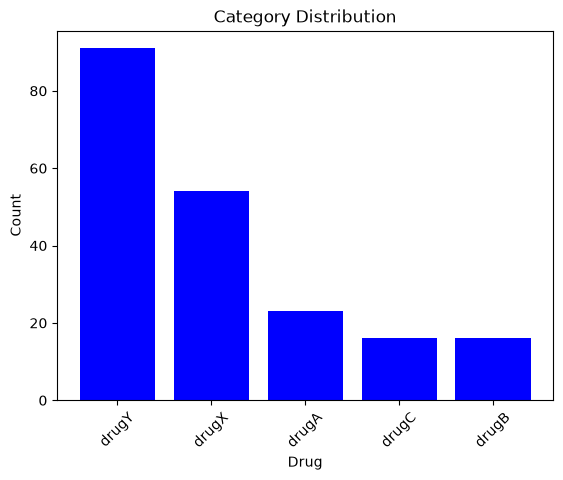

In [83]:
category_counts = df['Drug'].value_counts()

plt.bar(category_counts.index, category_counts.values, color='blue')
plt.xlabel('Drug')
plt.ylabel('Count')
plt.title('Category Distribution')
plt.xticks(rotation=45)
plt.show()

In [84]:
y = df["Drug"]
X = df.drop(["Drug", "Drug_num"], axis=1)

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [86]:
drug_tree = DecisionTreeClassifier(criterion='entropy', max_depth=4)
drug_tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [87]:
drug_tree_predictions = drug_tree.predict(X_test)

In [88]:
metrics.accuracy_score(y_test, drug_tree_predictions)

0.9666666666666667

[Text(0.625, 0.9, 'Na_to_K <= 14.839\nentropy = 1.983\nsamples = 140\nvalue = [19, 10, 12, 35, 64]\nclass = drugB'),
 Text(0.5, 0.7, 'BP <= 0.5\nentropy = 1.821\nsamples = 76\nvalue = [19, 10, 12, 35, 0]\nclass = drugA'),
 Text(0.5625, 0.8, 'True  '),
 Text(0.25, 0.5, 'Age <= 53.0\nentropy = 0.929\nsamples = 29\nvalue = [19, 10, 0, 0, 0]\nclass = drugY'),
 Text(0.125, 0.3, 'entropy = 0.0\nsamples = 19\nvalue = [19, 0, 0, 0, 0]\nclass = drugY'),
 Text(0.375, 0.3, 'entropy = 0.0\nsamples = 10\nvalue = [0, 10, 0, 0, 0]\nclass = drugC'),
 Text(0.75, 0.5, 'BP <= 1.5\nentropy = 0.82\nsamples = 47\nvalue = [0.0, 0.0, 12.0, 35.0, 0.0]\nclass = drugA'),
 Text(0.625, 0.3, 'Cholesterol <= 0.5\nentropy = 0.999\nsamples = 25\nvalue = [0, 0, 12, 13, 0]\nclass = drugA'),
 Text(0.5, 0.1, 'entropy = 0.0\nsamples = 12\nvalue = [0, 0, 12, 0, 0]\nclass = drugX'),
 Text(0.75, 0.1, 'entropy = 0.0\nsamples = 13\nvalue = [0, 0, 0, 13, 0]\nclass = drugA'),
 Text(0.875, 0.3, 'entropy = 0.0\nsamples = 22\nvalue 

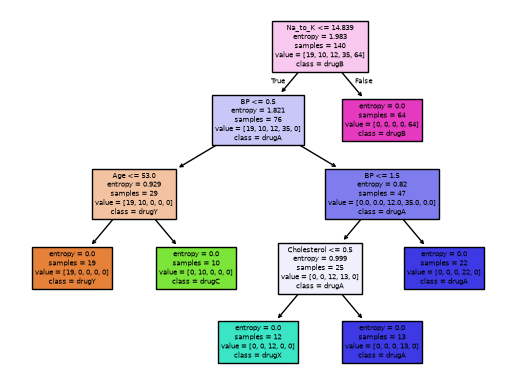

In [89]:
plot_tree(drug_tree, feature_names=X.columns, class_names=df['Drug'].unique(), filled=True)

In [90]:
drugTree = DecisionTreeClassifier(criterion="entropy", max_depth = 3)
drugTree.fit(X_train,y_train)
tree_predictions = drugTree.predict(X_test)
print("Decision Trees's Accuracy: ", metrics.accuracy_score(y_test, tree_predictions))

Decision Trees's Accuracy:  0.9
